# Monte Carlo — Heston + microstructure noise

ZMA05 ladder on simulated paths: fifth (all-sample RV) → fourth (sparse) → … → first_adj (TSRV).

**Decision:** `cont.sparse_rv_only` = **Kill** — first_adj RMSE ≈ 0.42× fourth (n=500).


In [1]:
from pathlib import Path
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path('/home/dev/srv/ares-microstructure/research/books/mn_tuwrv')
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'
sys.path.insert(0, str(BOOK.parents[2]))  # research/

def jload(rel):
    return json.loads((OUT / rel).read_text())

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing figure* `{p}` — run `scripts/build_notebook_figs.py`'))

bc = jload('blocker_close/blocker_close.json')
gc = jload('gap_close/gap_close.json')
mc = jload('monte_carlo/mc_summary.json')
p2 = jload('pass2/pass2_gates.json')
print('BOOK', BOOK)
print('figs', sorted(p.name for p in FIGS.glob('*.png')))


BOOK /home/dev/srv/ares-microstructure/research/books/mn_tuwrv
figs ['fig_clock_medians.png', 'fig_gate_counts.png', 'fig_mc_rmse_ladder.png', 'fig_mid_venue_split.png', 'fig_noise_vs_spread.png', 'fig_noise_vs_spread_gap_close.png', 'fig_ratio_hist.png', 'fig_tob_coverage.png', 'fig_tsrv_oos.png', 'signal_board.png']


**RMSE ladder** — `out/desk_synthesis/figs/fig_mc_rmse_ladder.png`

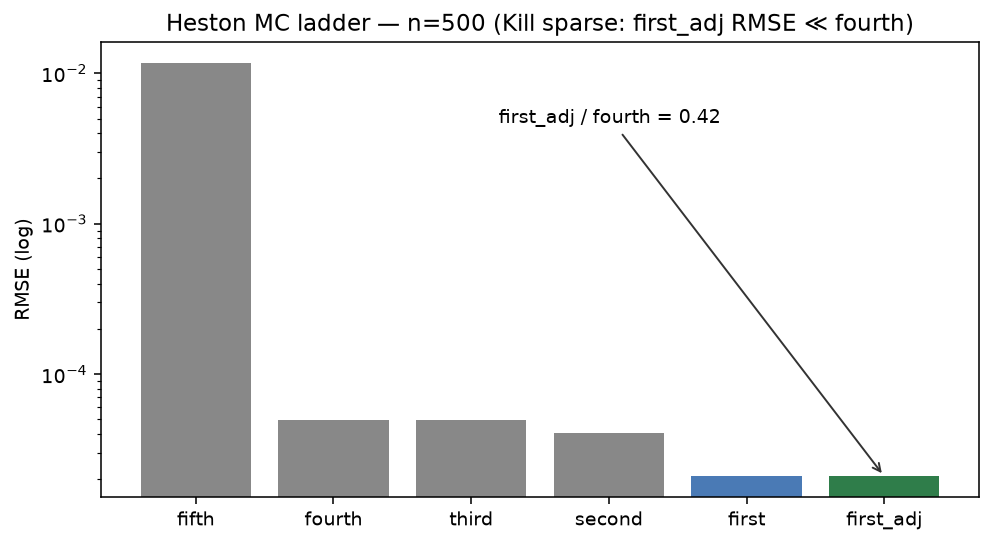

,bias,var,rmse,n
fifth,0.011695,1.911772e-08,0.011696,500.0
fourth,0.000038,1.021137e-09,0.000050,500.0
third,0.000038,1.021137e-09,0.000050,500.0
second,0.000035,4.247829e-10,0.000041,500.0
first,-0.000004,4.253555e-10,0.000021,500.0
first_adj,-0.000003,4.279867e-10,0.000021,500.0


first_adj/fourth RMSE 0.4192830273864627
heston params {'mu': 0.05, 'kappa': 5.0, 'alpha': 0.04, 'gamma': 0.5, 'rho': -0.5, 'noise_std': 0.0005, 'T': 0.003968253968253968, 'dt': 1.6958350291683626e-07}
EXP_REPORT:
 # Monte Carlo — EXP_REPORT (Pass 2)

## Sample
- n_sims: 500
- K: 300  step: 300
- Heston σ_ε=0.0005

| Estimator | Bias | Var | RMSE | n |
|-----------|------|-----|------|---|
| fifth | 0.0116949 | 1.91177e-08 | 0.0116957 | 500 |
| fourth | 3.83496e-05 | 1.02114e-09 | 4.98977e-05 | 500 |
| third | 3.83496e-05 | 1.02114e-09 | 4.98977e-05 | 500 |
| second | 3.52445e-05 | 4.24783e-10 | 4.0818e-05 | 500 |
| first | -3.76187e-06 | 4.25356e-10 | 2.09441e-05 | 500 |
| first_adj | -3.25097e-06 | 4.27987e-10 | 2.09213e-05 | 500 |

## Gate
- `cont.sparse_rv_only` → **Kill** — first_adj_rmse=2.09213e-05 fourth_rmse=4.98977e-05
- Artifact: `out/monte_carlo/mc_summary_pass2.json`



In [2]:
show_fig('fig_mc_rmse_ladder.png', 'RMSE ladder')
est = mc['estimators']
df = pd.DataFrame(est).T
display(df[['bias','var','rmse','n']])
print('first_adj/fourth RMSE', est['first_adj']['rmse']/est['fourth']['rmse'])
print('heston params', mc['heston'])
print('EXP_REPORT:\n', (BOOK/'chapters/monte_carlo/EXP_REPORT.md').read_text())


### Desk read

MC Kills **sparse-only** as a policy for this noise regime. That Kill is **independent** of tape OOS — tape may still Hold `cont.tsrv_first_adj` if the advantage is not significant out of sample.
